In [1]:
from geopy.geocoders import Nominatim
from geopy.geocoders import Photon
import matplotlib.pyplot as plt
import pandas as pd

from collections import Counter

In [2]:
loc = pd.read_csv('location.csv')
loc = pd.DataFrame(loc, columns=['commune','district' ,'province'])
commune = list(loc['commune'])
district = list(loc['district'])
province = list(loc['province'])

In [3]:
location = [[c, d, p] for c, d, p in zip(commune, district, province)]
loc = [[commune[0], district[0], province[0]]]
for i in range(len(commune)):
    tmp = [commune[i], district[i], province[i]]
    if tmp not in loc:
        if tmp[0]=='Hòa Tiến (ĐN)' or tmp[0]=='Hòa Tiến (TB)':
            tmp[0]='Hòa Tiến'
        loc.append(tmp)       

In [12]:
len(dict(Counter(province)))

15

In [4]:
locator = Nominatim(user_agent='epidemic_model')
photon = Photon()

In [5]:
X = []
l = []
Y = []
for i in range(len(commune)):
    if province[i]=='Đà Nẵng':
        location = photon.geocode("{}, {}, {}".format(commune[i], district[i], province[i]))
        l.append([commune[i], district[i], province[i]])
        X.append(location.longitude)
        Y.append(location.latitude)

In [6]:
danang = [[16.2661, 15.8786], [107.7642, 108.3849]]
latitude = danang[0]
longtitude = danang[1]

In [7]:
y_point = [latitude[0], latitude[0], latitude[1], latitude[1], latitude[0]]
x_point = [longtitude[0], longtitude[1], longtitude[1], longtitude[0], longtitude[0]]

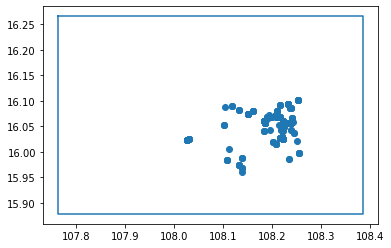

In [9]:
plt.imread('danang.png')
plt.plot(x_point, y_point)
plt.scatter(X, Y)
plt.savefig('geolayout.png')